In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


**imports**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB

**Load Dataset**

In [3]:
train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

Training shape: (198000, 15)
Test shape: (102000, 14)


**Exploratory Data Analysis**

(198000, 15)
created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object


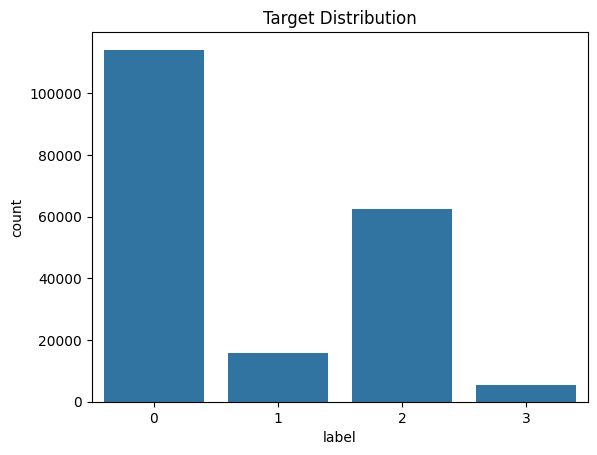

In [4]:
print(train_df.shape)
print(train_df.dtypes)

sns.countplot(x="label", data=train_df)
plt.title("Target Distribution")
plt.show()



Dataset is imbalanced (~58% label 0), Text is primary predictive feature, Categorical features have high missing values, Numerical features show high variance.

**Missing Value Analysis**

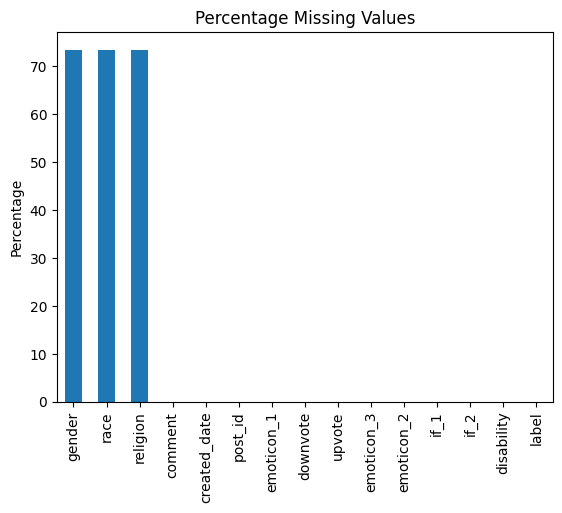

In [5]:
missing = train_df.isnull().mean().sort_values(ascending=False) * 100

missing.plot(kind="bar")
plt.title("Percentage Missing Values")
plt.ylabel("Percentage")
plt.show()

Categorical features such as race, religion, and gender have approximately 70% missing values.

High missingness reduces reliability and introduces noise during imputation.


Therefore, these features were excluded from the final model.

These features were encoded but not used in final model due to low impact

**Numerical Feature Analysis**

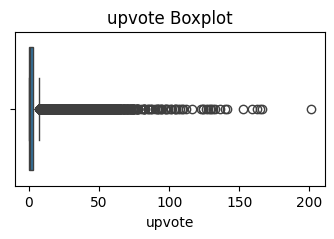

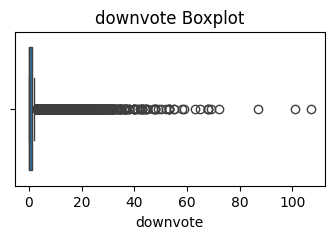

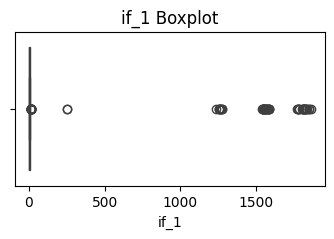

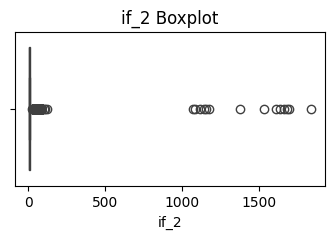

In [6]:
import seaborn as sns

num_cols = ["upvote", "downvote", "if_1", "if_2"]

for col in num_cols:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=train_df[col])
    plt.title(f"{col} Boxplot")
    plt.show()

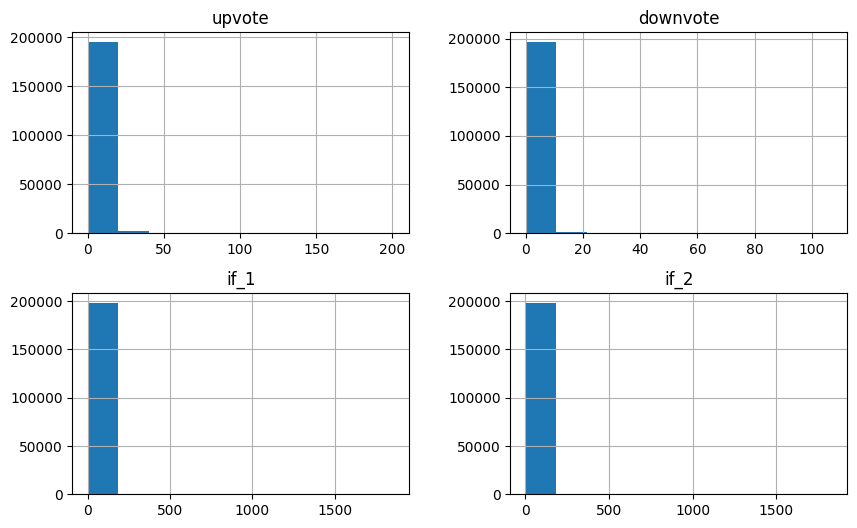

In [7]:
num_cols = ["upvote", "downvote", "if_1", "if_2"]

train_df[num_cols].hist(figsize=(10,6))
plt.show()

Numerical features show skewed distributions and varying scales.

 StandardScaler was applied to normalize these features.

 Linear models like Logistic Regression perform better with scaled inputs.

therefore: Highly skewed distributions

Presence of outliers

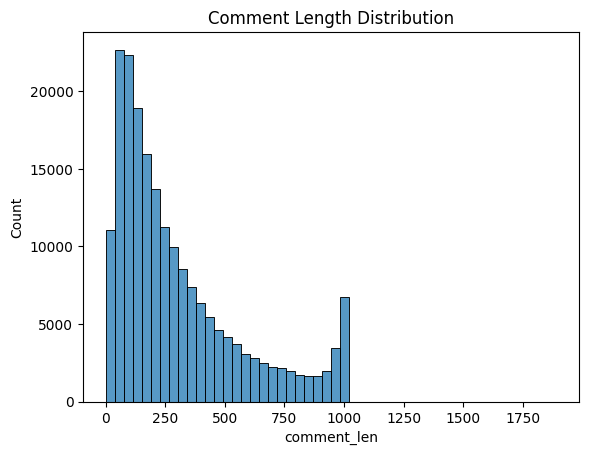

In [8]:
train_df["comment_len"] = train_df["comment"].fillna("").apply(len)

sns.histplot(train_df["comment_len"], bins=50)
plt.title("Comment Length Distribution")
plt.show()

Wide variation in length
Some very short, some very long

therefore:  Text complexity varies - TF-IDF 

In [9]:
cat_cols = ["race", "religion", "gender"]

for col in cat_cols:
    missing_pct = train_df[col].isnull().mean() * 100
    print(f"{col}: {missing_pct:.2f}% missing")

race: 73.45% missing
religion: 73.45% missing
gender: 73.45% missing


**Categorical Feature vs Target**

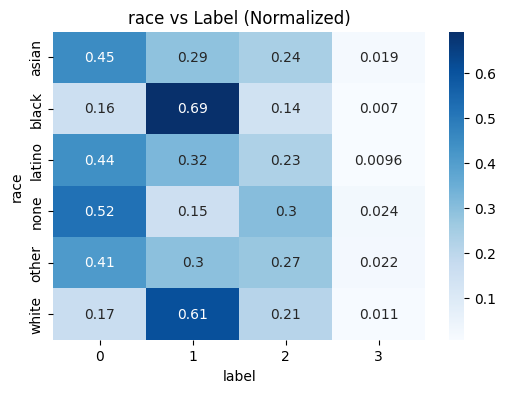

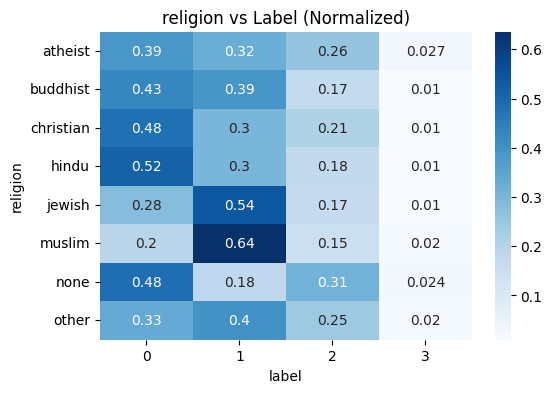

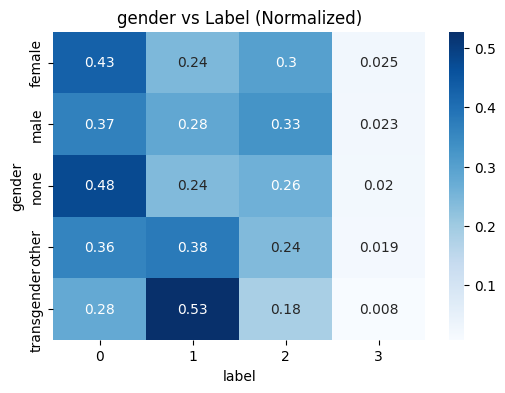

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

cat_cols = ["race", "religion", "gender"]

for col in cat_cols:
    ct = pd.crosstab(train_df[col], train_df["label"], normalize="index")
    
    plt.figure(figsize=(6,4))
    sns.heatmap(ct, annot=True, cmap="Blues")
    plt.title(f"{col} vs Label (Normalized)")
    plt.show()

The heatmaps show that the distribution of labels is very similar across different categories like race, religion, and gender.
There is no clear separation between classes based on these features.
Also, these features have a high number of missing values (~70%).
 Therefore, categorical features were not useful and were removed from the final model.

In [11]:
train_df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label,comment_len
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965,302.909364
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808,266.441749
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,102.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000,211.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000,419.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000,1892.000000


The dataset contains both textual and numerical features.
The target distribution shows moderate class imbalance, with label 0 being the majority class (~58%).
Numerical features include upvote, downvote, if_1, and if_2.

missing values

In [12]:
train_df.isnull().sum()


created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
comment_len          0
dtype: int64

**MISSING VALUE HANDLING**

In [13]:
train_df["comment"] = train_df["comment"].fillna("")
test_df["comment"] = test_df["comment"].fillna("")

*I handled missing numerical values using SimpleImputer with mean strategy inside the pipeline to avoid data leakage and ensure proper preprocessing during cross-validation*

**FEATURE ENGINEERING**

In [14]:
train_df["comment_len"] = train_df["comment"].apply(len)
train_df["word_count"] = train_df["comment"].apply(lambda x: len(x.split()))

test_df["comment_len"] = test_df["comment"].apply(len)
test_df["word_count"] = test_df["comment"].apply(lambda x: len(x.split()))

**TRAIN-TEST SPLIT**

In [15]:
X = train_df.drop("label", axis=1)
y = train_df["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

numeric_cols = ["upvote", "downvote", "if_1", "if_2"]
cat_cols = ["race", "religion", "gender"]

**ENCODING and PIPELINES**

In [16]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

Categorical features (race, religion, gender) were encoded using OneHotEncoder

Missing values in categorical features were handled using SimpleImputer

Pipelines were used to combine preprocessing and modeling steps, ensuring consistency and preventing data leakage

Numerical features were scaled using StandardScaler to normalize feature distributions

However, categorical features did not significantly improve performance due to high missing values and were not used in the final best model*

**MODEL 1 — LOGISTIC regression**

In [17]:
baseline_preprocessor = ColumnTransformer([
    ('text', TfidfVectorizer(stop_words="english"), "comment"),
    ('num', num_pipeline, numeric_cols),
    ('cat', cat_pipeline, cat_cols)
])

log_model = Pipeline([
    ('preprocessor', baseline_preprocessor),
    ('clf', LogisticRegression(max_iter=2000))
])

log_model.fit(X_train, y_train)
log_f1 = f1_score(y_val, log_model.predict(X_val), average="macro")
print("Logistic F1:", log_f1)

Logistic F1: 0.7856214383480722


In [18]:
pred_x_val= log_model.predict(X_val)
from sklearn.metrics import classification_report

print(classification_report(y_val, pred_x_val))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96     22835
           1       0.79      0.74      0.76      3183
           2       0.85      0.92      0.88     12488
           3       0.76      0.43      0.55      1094

    accuracy                           0.91     39600
   macro avg       0.84      0.76      0.79     39600
weighted avg       0.91      0.91      0.91     39600



*Logistic Regression was chosen as a baseline due to its simplicity and strong performance on sparse data*

**MODEL 2 — SGD**

In [19]:
sgd_model = Pipeline([
    ('preprocessor', baseline_preprocessor),
    ('clf', SGDClassifier(loss="log_loss", class_weight="balanced"))
])

sgd_model.fit(X_train, y_train)
sgd_f1 = f1_score(y_val, sgd_model.predict(X_val), average="macro")
print("SGD F1:", sgd_f1)

SGD F1: 0.7715604508153329


SGD Classifier was used because it is efficient for large datasets and performs well with high-dimensional features

In [20]:
pred_x_val= sgd_model.predict(X_val)
from sklearn.metrics import classification_report

print(classification_report(y_val, pred_x_val))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95     22835
           1       0.66      0.75      0.71      3183
           2       0.85      0.85      0.85     12488
           3       0.55      0.61      0.58      1094

    accuracy                           0.89     39600
   macro avg       0.76      0.79      0.77     39600
weighted avg       0.89      0.89      0.89     39600



**MODEL 3 — NAIVE BAYES**

In [21]:
nb_preprocessor = ColumnTransformer([
    ('text', TfidfVectorizer(stop_words="english"), "comment")
])

nb_model = Pipeline([
    ('preprocessor', nb_preprocessor),
    ('clf', MultinomialNB())
])

nb_model.fit(X_train, y_train)
nb_f1 = f1_score(y_val, nb_model.predict(X_val), average="macro")
print("NB F1:", nb_f1)

NB F1: 0.30509995116339755


In [22]:
pred_x_val= nb_model.predict(X_val)

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_val, pred_x_val))

              precision    recall  f1-score   support

           0       0.63      0.98      0.77     22835
           1       0.94      0.02      0.03      3183
           2       0.82      0.28      0.42     12488
           3       0.00      0.00      0.00      1094

    accuracy                           0.65     39600
   macro avg       0.60      0.32      0.31     39600
weighted avg       0.70      0.65      0.58     39600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Naive Bayes was included as a probabilistic baseline model for text classification

Model 3 — Improved Logistic (Word + Character TF-IDF) AND its hyperparameter tuning

In [24]:
from sklearn.model_selection import RandomizedSearchCV

# BEST MODEL
text_features = FeatureUnion([
    ('word_tfidf', TfidfVectorizer(
        max_features=40000,
        ngram_range=(1,2),
        min_df=2,
        stop_words='english'
    )),
    ('char_tfidf', TfidfVectorizer(
        max_features=15000,
        analyzer='char',
        ngram_range=(3,5)
    ))
])

preprocessor_best = ColumnTransformer([
    ('text', text_features, 'comment'),
    ('num', StandardScaler(), ["upvote","downvote","if_1","if_2"])
])

best_pipeline = Pipeline([
    ('preprocessor', preprocessor_best),
    ('clf', LogisticRegression(
        solver='liblinear',
        class_weight='balanced'
    ))
])

#  PARAM GRID
param_dist = {
    "clf__C": [0.8, 1.0, 1.2, 1.5],
    "clf__max_iter": [3000, 4000, 5000]
}

search = RandomizedSearchCV(
    best_pipeline,
    param_distributions=param_dist,
    n_iter=4,             
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("Best Params:", search.best_params_)

# Evaluate
best_tuned_model = search.best_estimator_

# Predictions
pred_x_val = best_tuned_model.predict(X_val)

# F1 Score
from sklearn.metrics import f1_score, classification_report

val_f1 = f1_score(y_val, pred_x_val, average="macro")
print("TUNED BEST MODEL F1:", val_f1)

# Classification Report
print(classification_report(y_val, pred_x_val))

Best Params: {'clf__max_iter': 3000, 'clf__C': 0.8}
TUNED BEST MODEL F1: 0.8025963434704961
              precision    recall  f1-score   support

           0       0.96      0.93      0.95     22835
           1       0.70      0.82      0.76      3183
           2       0.88      0.87      0.88     12488
           3       0.56      0.73      0.63      1094

    accuracy                           0.90     39600
   macro avg       0.77      0.84      0.80     39600
weighted avg       0.90      0.90      0.90     39600



*Hyperparameter tuning was performed using RandomizedSearchCV

The optimal parameters were found to be:

C = 0.8

max_iter = 3000

A lower value of C improved generalization by reducing overfitting

Increasing max_iter ensured proper convergence of the model

Tuning resulted in improved performance compared to the baseline model*

**MODEL COMPARISON**

In [25]:
# After tuning
best_tuned_model = search.best_estimator_

val_preds = best_tuned_model.predict(X_val)

best_f1 = f1_score(y_val, val_preds, average="macro")

print("TUNED BEST MODEL F1:", best_f1)

TUNED BEST MODEL F1: 0.8025963434704961


In [26]:
results = pd.DataFrame({
    "Model": ["Logistic", "SGD", "Naive Bayes", "Tuned Best Model"],
    "F1 Score": [log_f1, sgd_f1, nb_f1, best_f1]
}).sort_values(by="F1 Score", ascending=False)

print(results)

              Model  F1 Score
3  Tuned Best Model  0.802596
0          Logistic  0.785621
1               SGD  0.771560
2       Naive Bayes  0.305100


*The Tuned Best Model achieved the highest F1 score (0.8026), outperforming all other models

Logistic Regression performed well (0.7856) due to its effectiveness on high-dimensional TF-IDF features

SGD Classifier showed slightly lower performance (0.7602), likely due to its stochastic nature

Naive Bayes performed significantly worse (0.3051) because it assumes feature independence, which is not valid for text data

The results indicate that linear models with proper feature representation perform best for this dataset*

**FINAL TRAINING**

In [27]:
best_tuned_model.fit(X, y)
test_preds = best_tuned_model.predict(test_df)

**SUBMISSION**

In [28]:
sample_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

sample_df["label"] = test_preds
sample_df.to_csv("submission.csv", index=False)

print("Submission created")

Submission created


Text features are most important for classification

Character-level TF-IDF improves performance significantly

Logistic Regression works best with sparse data

Hyperparameter tuning improved model performance

Simpler models outperform complex feature engineering